In [69]:
# importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress


In [70]:
# Loading the required dataset
nav_df = pd.read_csv("../data/processed/clean_nav_history.csv")

scheme_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")


In [71]:
# verifying the dataframes
nav_df.columns, scheme_df.columns, benchmark_df.columns

(Index(['amfi_code', 'date', 'nav'], dtype='str'),
 Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
        'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
        'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
        'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
        'morningstar_rating', 'risk_grade'],
       dtype='str'),
 Index(['date', 'index_name', 'close_value'], dtype='str'))

In [72]:
# fetching the .head() for each dataset
nav_df.head(), scheme_df.head(), benchmark_df.head()

(   amfi_code        date       nav
 0     100016  2022-01-03  520.4608
 1     100016  2022-01-04  515.0971
 2     100016  2022-01-05  521.7239
 3     100016  2022-01-06  515.7880
 4     100016  2022-01-07  515.1639,
    amfi_code                                   scheme_name       fund_house  \
 0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
 1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
 2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
 3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
 4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   
 
     category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
 0  Large Cap  Regular           12.42           12.36           14.45   
 1  Large Cap   Direct           15.25           11.30           14.23   
 2  Small Cap  Regular           24.56           23.39           20.67   
 3  S

In [73]:
# convert the date columns to datetime format
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [74]:
# sorting the data
nav_df = nav_df.sort_values(
    ['amfi_code','date']
)
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [75]:
# Calculating the daily returns
nav_df['daily_return'] = (nav_df.groupby('amfi_code')['nav'].pct_change())
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [76]:
# Removing the NaN Returns
returns_df = nav_df.dropna(subset=['daily_return'])
returns_df.head(10)

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073
10,100016,2022-01-17,514.7627,0.000776


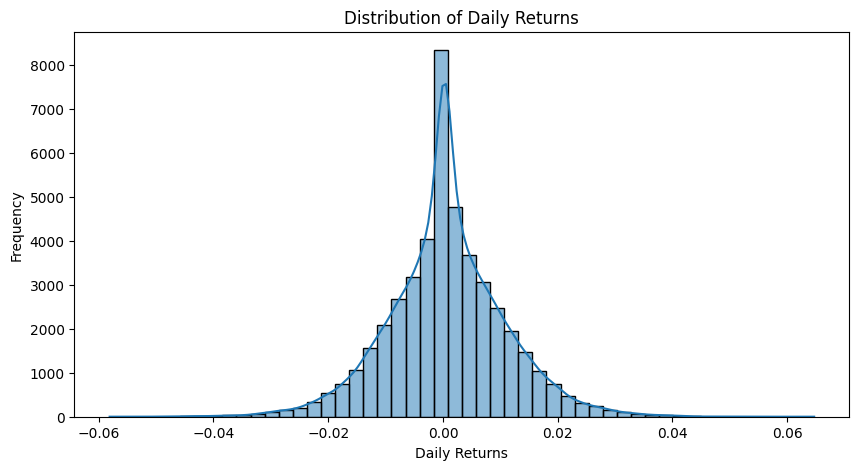

In [77]:
# Now to Validate Distributions
plt.figure(figsize=(10,5))

sns.histplot(
    returns_df['daily_return'],
    bins = 50,
    kde = True
)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.show()

In [78]:
plt.savefig("../reports/charts/daily_return_distribution.png",
        bbox_inches = 'tight'
)
plt.show()

<Figure size 640x480 with 0 Axes>

## Daily Return Distribution Analysis

The distribution of daily returns is centered around zero, indicating that most daily NAV movements are relatively small.

The bell-shaped pattern suggests that returns approximately follow a normal distribution, which is commonly observed in financial markets.

While most observations are clustered near the mean, a few extreme positive and negative returns are visible, representing periods of higher market volatility.

Understanding the return distribution is essential for risk assessment and performance analytics.

In [79]:
# CAGR Calculation for 1,3,5 year for all funds
# checking date range
returns_df.groupby('amfi_code')['date'].agg(['min','max']).head()

,min,max
amfi_code,,
100016,2022-01-04,2026-05-29
100025,2022-01-04,2026-05-29
100033,2022-01-04,2026-05-29
101206,2022-01-04,2026-05-29
101207,2022-01-04,2026-05-29


In [80]:
cagr_df = scheme_df[[
    'amfi_code',
    'scheme_name',
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct'
]].copy()
cagr_df.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [81]:
# view top funds by 3_year cagr
top_cagr = cagr_df.sort_values(
    'return_3yr_pct',
    ascending = False
)
top_cagr.head(10)

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
29,101207,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88
39,149324,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61
21,120842,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75
12,120505,ICICI Pru Midcap Fund - Regular - Growth,14.02,18.08,17.55
38,149323,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69


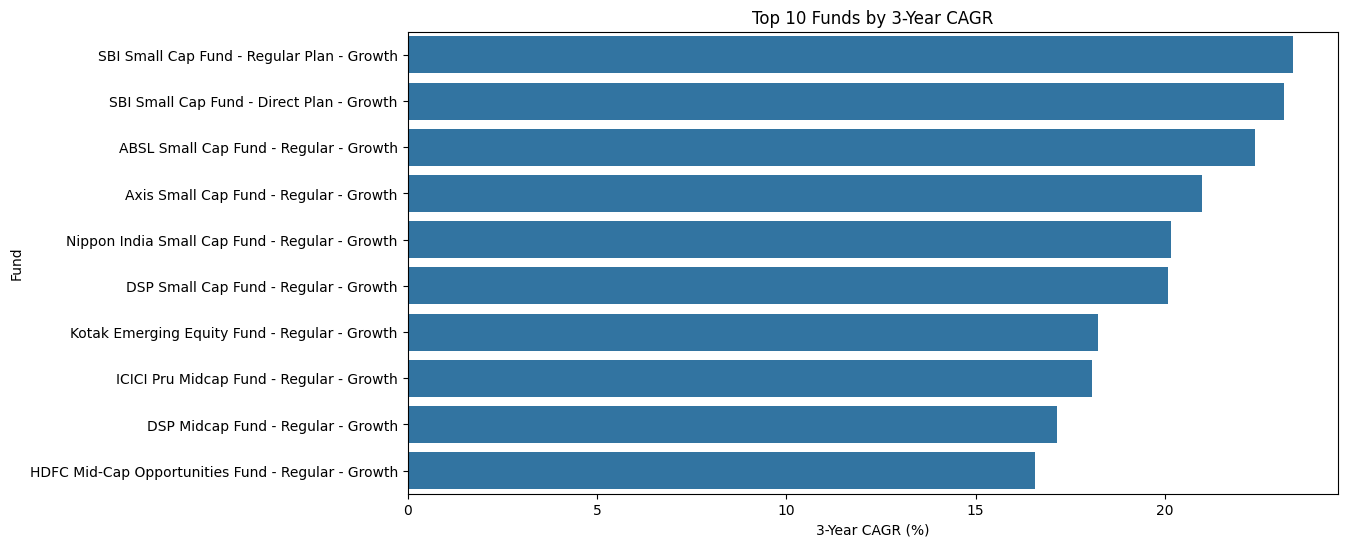

In [82]:
# Create CAGR Comparison Chart
top10 = top_cagr.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='return_3yr_pct',
    y='scheme_name'
)
plt.title("Top 10 Funds by 3-Year CAGR")
plt.xlabel('3-Year CAGR (%)')
plt.ylabel('Fund')

plt.savefig("../reports/charts/top10_cagr.png", bbox_inches='tight')
plt.show()

## CAGR Analysis

The comparison of 3-year CAGR values shows significant variation in long-term fund performance across the mutual fund universe.

The top-performing funds have consistently generated higher annualized returns over the last three years, indicating strong portfolio management and favorable market exposure.

CAGR provides a standardized measure of growth and enables meaningful comparison between funds with different investment strategies.

Funds with higher CAGR values may offer stronger wealth creation potential, although risk metrics should also be considered before making investment decisions.

In [83]:
# 3: Sharpe Ratio Ranking
scheme_df[['scheme_name','sharpe_ratio']].head()

,scheme_name,sharpe_ratio
0,SBI Bluechip Fund - Regular Plan - Growth,0.88
1,SBI Bluechip Fund - Direct Plan - Growth,0.81
2,SBI Small Cap Fund - Regular Plan - Growth,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,0.93
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


In [84]:
# Ranking all Funds by Sharpe Ratio
sharpe_df = scheme_df[[
    'amfi_code',
    'scheme_name',
    'sharpe_ratio'
]].copy()

sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

sharpe_df.head(10)

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,118636,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.00


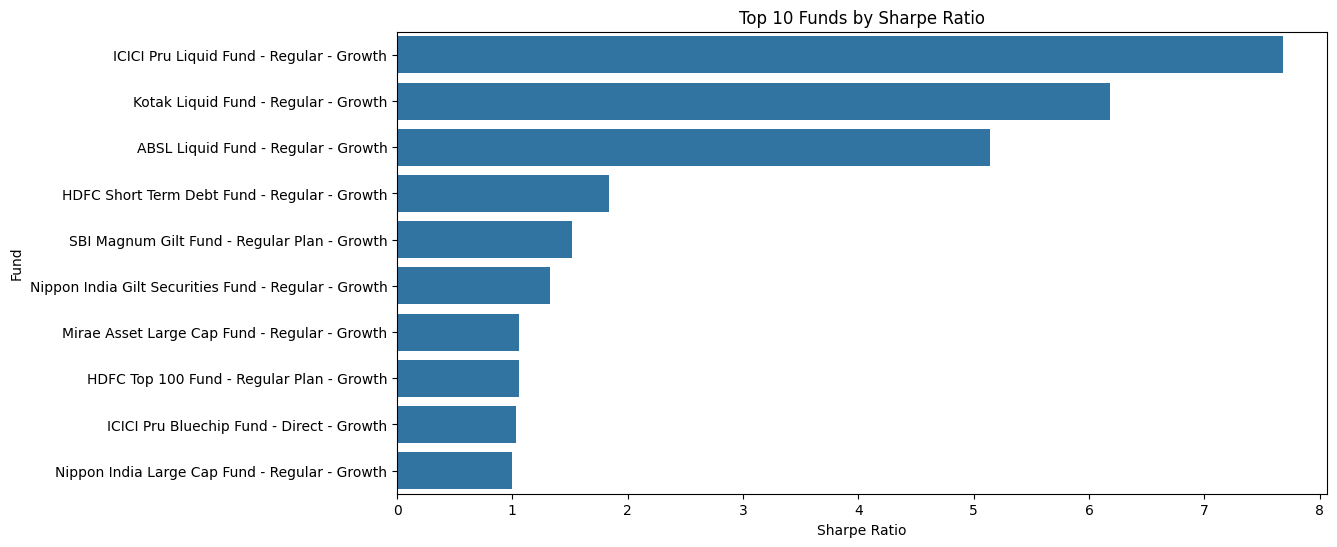

In [85]:
# Top 10 Sharpe Ratio Chart
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title('Top 10 Funds by Sharpe Ratio')

plt.xlabel('Sharpe Ratio')
plt.ylabel('Fund')

plt.savefig("../reports/charts/top10_sharpe_ratio.png", bbox_inches = 'tight')
plt.show()

## Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted returns by comparing excess return to portfolio volatility.

Funds with higher Sharpe Ratios have delivered superior returns relative to the amount of risk taken.

The top-ranked funds demonstrate efficient risk management and strong reward-to-risk characteristics.

Investors often use Sharpe Ratio as a key metric when comparing investment alternatives with similar objectives.

In [86]:
# 4: Sortino Ratio Ranking

# Creating Ranking table
sortino_df = scheme_df[[
    'amfi_code',
    'scheme_name',
    'sortino_ratio'
]].copy()

sortino_df = sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
)

top10_sortino = sortino_df.head(10)

top10_sortino

,amfi_code,scheme_name,sortino_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,120844,Kotak Liquid Fund - Regular - Growth,9.70
30,101208,ABSL Liquid Fund - Regular - Growth,8.76
9,100025,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,118636,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.68
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.66


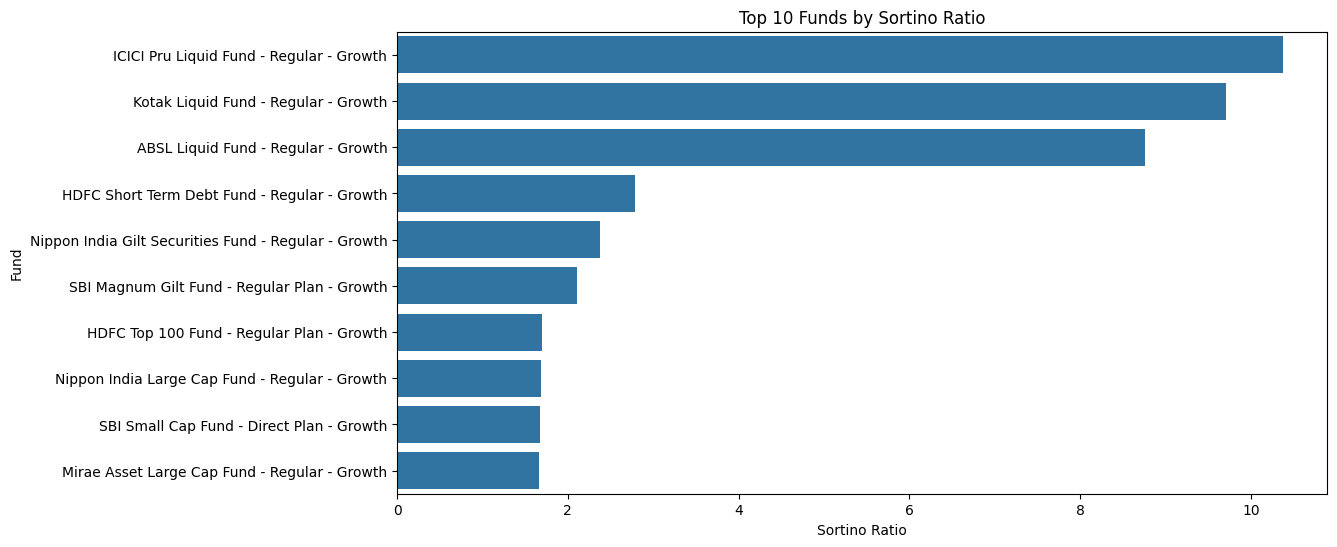

In [87]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x='sortino_ratio',
    y='scheme_name'
)

plt.title('Top 10 Funds by Sortino Ratio')

plt.xlabel('Sortino Ratio')
plt.ylabel('Fund')

plt.savefig(
    "../reports/charts/top10_sortino_ratio.png",
    bbox_inches='tight'
)

plt.show()

## Sortino Ratio Analysis

The Sortino Ratio evaluates risk-adjusted returns by considering only downside volatility, making it particularly useful for measuring investment performance from an investor’s perspective.

Funds with higher Sortino Ratios have generated stronger returns while effectively limiting negative return fluctuations.

Compared to the Sharpe Ratio, the Sortino Ratio provides a more focused assessment of downside risk and helps identify funds with superior downside protection.

The top-ranked funds demonstrate strong return generation with relatively low downside volatility.

In [88]:
# 5 : Alpha & Beta Analysis
benchmark_df['index_name'].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [89]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [90]:
# Creating NIFTY100 Dataset
nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [91]:
nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [92]:
# Calculating NIFTY100 Daily Returns
nifty100['market_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,market_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [93]:
# Removing the First NaN Value
nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,market_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [94]:
# Verifying Market Returns
nifty100[['date','market_return']].head()

,date,market_return
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150
1155,2022-01-10,-0.008351


In [95]:
# 6: Creating Fund Returns Dataset
returns_df.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [96]:
returns_df.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [97]:
# Merging Fund Returns with Market returns
merged_df = pd.merge(
    returns_df,
    nifty100[['date', 'market_return']],
    on='date',
    how='inner'
)

merged_df.head()

,amfi_code,date,nav,daily_return,market_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [98]:
# Verifying Merge
merged_df[['date',
           'amfi_code',
           'daily_return',
           'market_return']].head()

,date,amfi_code,daily_return,market_return
0,2022-01-04,100016,-0.010306,-0.013540
1,2022-01-05,100016,0.012865,0.004003
2,2022-01-06,100016,-0.011377,-0.002935
3,2022-01-07,100016,-0.001210,0.006150
4,2022-01-10,100016,-0.008639,-0.008351


In [100]:
# Calculating Alpha & Beta
alpha_beta_results = []

for fund in merged_df['amfi_code'].unique():

    temp = merged_df[
        merged_df['amfi_code'] == fund
    ]

    slope, intercept, r_value, p_value, std_err = linregress(
        temp['market_return'],
        temp['daily_return']
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append([
        fund,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [101]:
# Saving alpha_beta.csv
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [102]:
# viewing Top Alpha Funds
top_alpha = alpha_beta_df.sort_values(
    'alpha',
    ascending=False
)

top_alpha.head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


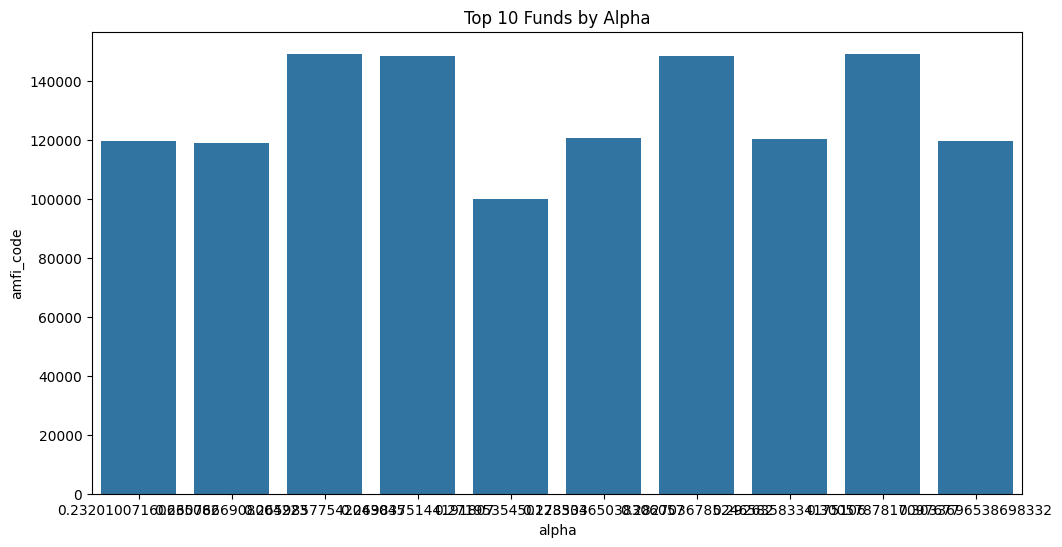

In [103]:
# Alpha Chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha.head(10),
    x='alpha',
    y='amfi_code'
)

plt.title('Top 10 Funds by Alpha')

plt.show()

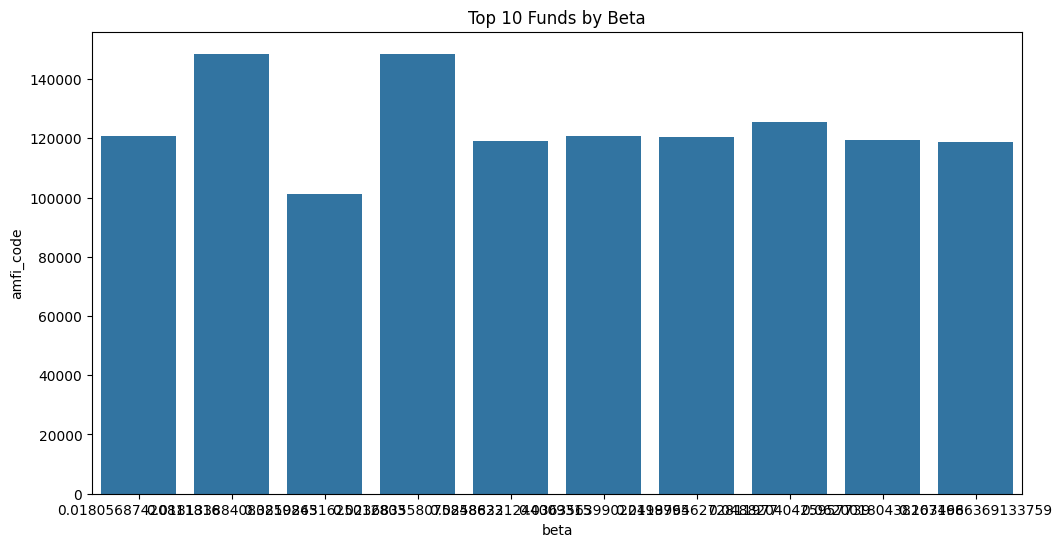

In [104]:
# Beta Chart
top_beta = alpha_beta_df.sort_values(
    'beta',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_beta.head(10),
    x='beta',
    y='amfi_code'
)

plt.title('Top 10 Funds by Beta')

plt.show()

In [105]:
# verifyign the alpha_beta_df 

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


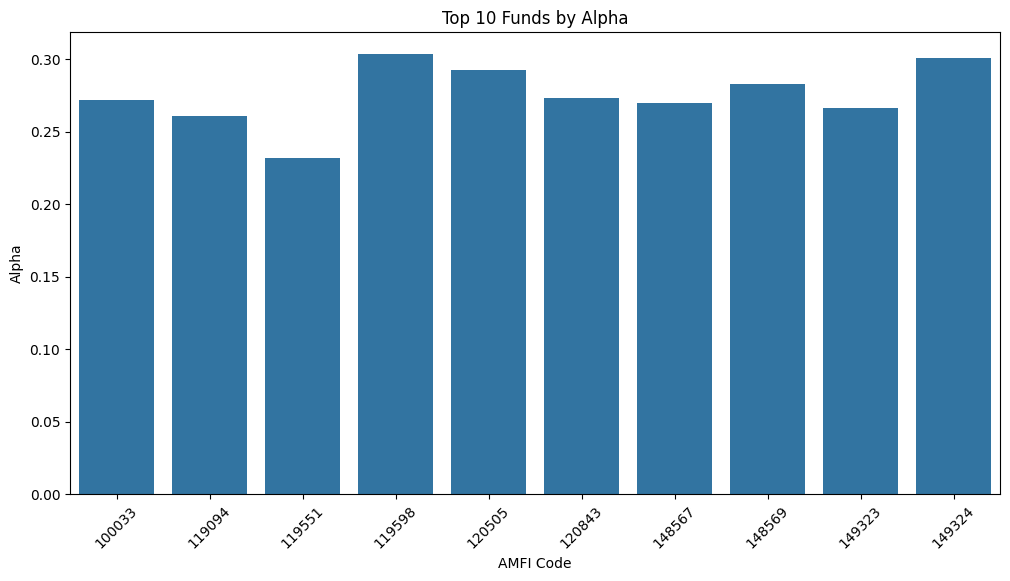

In [106]:
# Alpha and Beta charts saving
top_alpha = alpha_beta_df.sort_values(
    'alpha',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x='amfi_code',
    y='alpha'
)

plt.title('Top 10 Funds by Alpha')
plt.xlabel('AMFI Code')
plt.ylabel('Alpha')

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/top10_alpha.png",
    bbox_inches='tight'
)

plt.show()

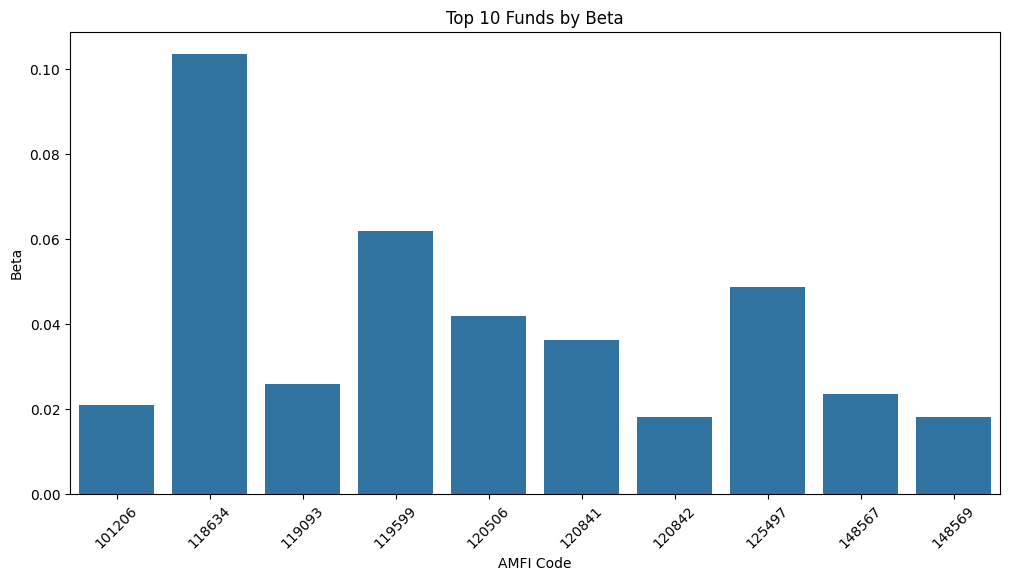

In [107]:
top_beta = alpha_beta_df.sort_values(
    'beta',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_beta,
    x='amfi_code',
    y='beta'
)

plt.title('Top 10 Funds by Beta')
plt.xlabel('AMFI Code')
plt.ylabel('Beta')

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/top10_beta.png",
    bbox_inches='tight'
)

plt.show()

## Alpha and Beta Analysis

Alpha measures the excess return generated by a fund beyond what would be expected based on its market exposure.

Funds with positive Alpha values have outperformed their benchmark after adjusting for market risk, indicating superior fund management.

Beta measures a fund's sensitivity to market movements. A Beta greater than 1 indicates higher volatility than the market, while a Beta below 1 suggests lower market sensitivity.

The analysis helps identify funds that have delivered strong risk-adjusted performance and understand their relationship with broader market movements.

In [108]:
# Maximum Drawdown
# inspecting the nav dataset again
nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [109]:
nav_df.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [110]:
# Calculating running maximum nav
nav_df['running_max'] = (
    nav_df.groupby('amfi_code')['nav']
    .cummax()
)

nav_df.head()

,amfi_code,date,nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [111]:
# calculating drawdown
nav_df['drawdown'] = (
    nav_df['nav'] /
    nav_df['running_max']
) - 1

nav_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [112]:
# calculating maximum drawdown for every fund
mdd_df = (
    nav_df.groupby('amfi_code')['drawdown']
    .min()
    .reset_index()
)

mdd_df.columns = [
    'amfi_code',
    'max_drawdown'
]

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [113]:
# calculating top 10 worst drawdown
worst_mdd = mdd_df.sort_values(
    'max_drawdown'
)

worst_mdd.head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


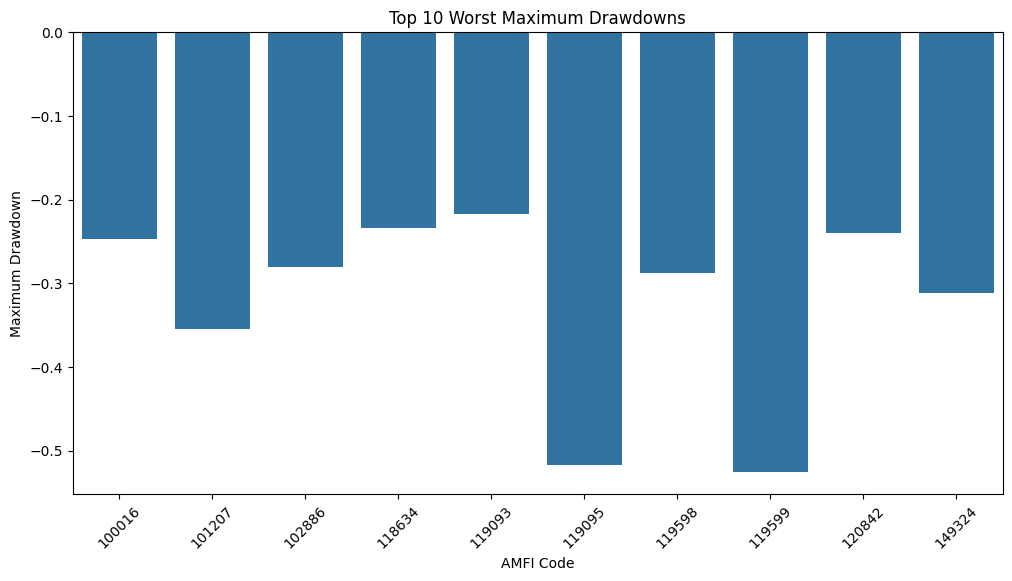

In [114]:
# creating drawdown chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_mdd.head(10),
    x='amfi_code',
    y='max_drawdown'
)

plt.title('Top 10 Worst Maximum Drawdowns')

plt.xlabel('AMFI Code')
plt.ylabel('Maximum Drawdown')

plt.xticks(rotation=45)

plt.show()

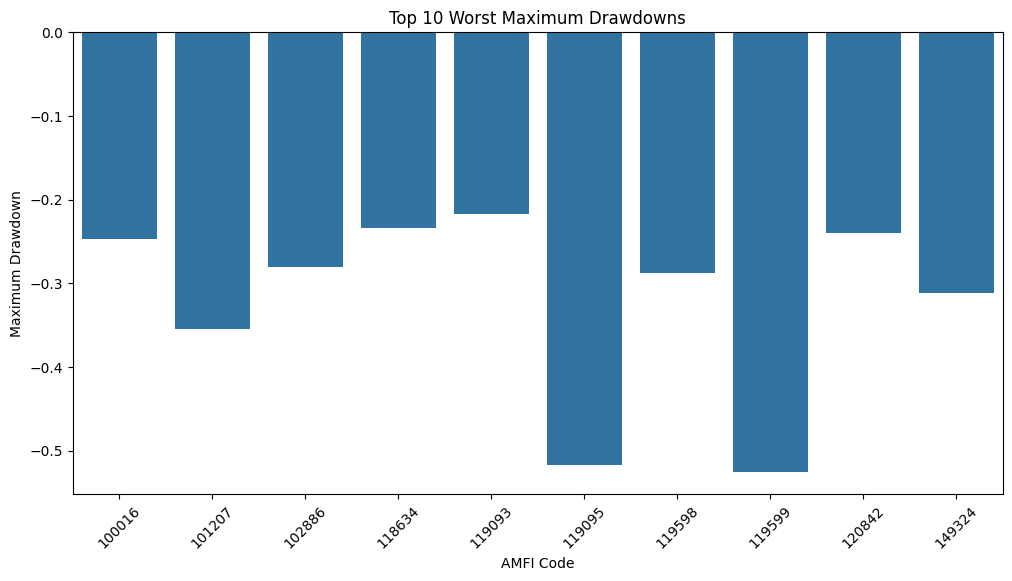

In [115]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_mdd.head(10),
    x='amfi_code',
    y='max_drawdown'
)

plt.title('Top 10 Worst Maximum Drawdowns')

plt.xlabel('AMFI Code')
plt.ylabel('Maximum Drawdown')

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/max_drawdown.png",
    bbox_inches='tight'
)

plt.show()

## Maximum Drawdown Analysis

Maximum Drawdown represents the largest peak-to-trough decline experienced by a fund during the analysis period.

Funds with larger negative drawdowns experienced more severe losses before recovering, indicating higher downside risk.

The drawdown metric complements return-based measures by highlighting the potential magnitude of losses investors may face during adverse market conditions.

Investors generally prefer funds with lower drawdowns, as they indicate stronger capital preservation during market downturns.

In [116]:
# Creating Scorecard dataset
scheme_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [117]:
# merge alpha and drawdown
scorecard_df = scheme_df[[
    'amfi_code',
    'scheme_name',
    'return_3yr_pct',
    'sharpe_ratio',
    'expense_ratio_pct'
]].copy()

scorecard_df = scorecard_df.merge(
    alpha_beta_df,
    on='amfi_code',
    how='left'
)

scorecard_df = scorecard_df.merge(
    mdd_df,
    on='amfi_code',
    how='left'
)

scorecard_df.head()

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,alpha,beta,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,0.88,1.54,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.81,0.66,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.43,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,0.72,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.52,0.77,0.056209,-0.006414,-0.043287


In [118]:
# Creating Rank
# Higher is better
scorecard_df['return_rank'] = scorecard_df['return_3yr_pct'].rank(
    ascending=False
)

scorecard_df['sharpe_rank'] = scorecard_df['sharpe_ratio'].rank(
    ascending=False
)

scorecard_df['alpha_rank'] = scorecard_df['alpha'].rank(
    ascending=False
)

# Lower expense ratio is better
scorecard_df['expense_rank'] = scorecard_df['expense_ratio_pct'].rank(
    ascending=True
)

# Smaller drawdown is better
scorecard_df['drawdown_rank'] = scorecard_df['max_drawdown'].rank(
    ascending=False
)

scorecard_df.head()

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,0.88,1.54,0.232010,-0.031751,-0.150124,26.0,26.5,10.0,30.5,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.81,0.66,0.198686,-0.026159,-0.118035,34.0,35.5,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.43,0.303370,-0.023196,-0.287060,1.0,18.0,1.0,21.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,0.72,0.048824,0.062002,-0.525742,2.0,19.5,36.0,5.5,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.52,0.77,0.056209,-0.006414,-0.043287,38.0,5.0,34.0,9.0,5.0


In [119]:
# checking weighted score
scorecard_df['fund_score'] = (

    scorecard_df['return_rank'] * 0.30 +

    scorecard_df['sharpe_rank'] * 0.25 +

    scorecard_df['alpha_rank'] * 0.20 +

    scorecard_df['expense_rank'] * 0.15 +

    scorecard_df['drawdown_rank'] * 0.10

)

In [120]:
# converting to 0-100 scale
scorecard_df['fund_score'] = (

    scorecard_df['fund_score'] /
    scorecard_df['fund_score'].max()

) * 100

scorecard_df.head()

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,0.88,1.54,0.232010,-0.031751,-0.150124,26.0,26.5,10.0,30.5,17.0,74.487285
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.81,0.66,0.198686,-0.026159,-0.118035,34.0,35.5,15.0,4.0,11.0,78.014766
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.43,0.303370,-0.023196,-0.287060,1.0,18.0,1.0,21.0,36.0,38.556194
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,0.72,0.048824,0.062002,-0.525742,2.0,19.5,36.0,5.5,40.0,57.424118
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,1.52,0.77,0.056209,-0.006414,-0.043287,38.0,5.0,34.0,9.0,5.0,69.893355


In [121]:
# Ranking funds
scorecard_df = scorecard_df.sort_values(
    'fund_score',
    ascending=False
)

scorecard_df.head(10)

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
24,119092,Axis Bluechip Fund - Regular - Growth,11.84,0.85,1.64,0.068995,0.009731,-0.144016,31.0,31.0,30.0,39.5,15.0,100.000000
20,120841,Kotak Bluechip Fund - Regular - Growth,12.25,0.87,1.59,0.130429,0.036356,-0.175736,28.0,29.0,25.0,35.0,24.0,92.863002
32,102886,UTI Mid Cap Fund - Regular - Growth,15.61,0.82,1.51,0.028969,-0.042125,-0.280011,12.0,33.5,40.0,24.5,35.0,89.089418
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,11.54,0.82,1.42,0.177033,-0.040269,-0.138979,33.0,33.5,17.0,20.0,14.0,85.561936
25,119093,Axis Bluechip Fund - Direct - Growth,12.14,0.87,0.75,0.082328,0.025883,-0.217514,29.0,29.0,28.0,8.0,31.0,84.823626
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,0.80,1.60,0.282704,0.018134,-0.163967,23.0,38.5,4.0,36.5,21.0,81.706317
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.81,0.66,0.198686,-0.026159,-0.118035,34.0,35.5,15.0,4.0,11.0,78.014766
37,149322,DSP Top 100 Equity Fund - Regular - Growth,12.82,0.92,1.54,0.131732,-0.004050,-0.148446,25.0,21.0,24.0,30.5,16.0,77.850697
31,102885,UTI Nifty 50 Index Fund - Regular - Growth,12.10,0.93,1.57,0.170488,-0.019487,-0.108599,30.0,19.5,19.0,34.0,7.0,77.030353
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,15.29,0.80,0.78,0.119891,0.009054,-0.211173,14.0,38.5,26.0,10.0,29.0,76.866284


In [126]:
max_rank = len(scorecard_df)

scorecard_df['return_score'] = max_rank - scorecard_df['return_rank'] + 1
scorecard_df['sharpe_score'] = max_rank - scorecard_df['sharpe_rank'] + 1
scorecard_df['alpha_score'] = max_rank - scorecard_df['alpha_rank'] + 1
scorecard_df['expense_score'] = max_rank - scorecard_df['expense_rank'] + 1
scorecard_df['drawdown_score'] = max_rank - scorecard_df['drawdown_rank'] + 1

In [127]:
scorecard_df['fund_score'] = (
    scorecard_df['return_score'] * 0.30 +
    scorecard_df['sharpe_score'] * 0.25 +
    scorecard_df['alpha_score'] * 0.20 +
    scorecard_df['expense_score'] * 0.15 +
    scorecard_df['drawdown_score'] * 0.10
)

In [128]:
scorecard_df['fund_score'] = (
    scorecard_df['fund_score']
    / scorecard_df['fund_score'].max()
) * 100

In [129]:
scorecard_df = scorecard_df.sort_values(
    'fund_score',
    ascending=False
)

scorecard_df.head(10)

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,return_score,sharpe_score,alpha_score,expense_score,drawdown_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.43,0.303370,-0.023196,-0.287060,1.0,18.0,1.0,21.0,36.0,100.000000,40.0,23.0,40.0,20.0,5.0
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,0.98,1.45,0.273305,-0.022830,-0.129740,11.0,12.0,5.0,22.0,13.0,99.487179,30.0,29.0,36.0,19.0,28.0
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,0.95,1.36,0.292636,0.000549,-0.181885,8.0,17.0,3.0,15.0,25.0,99.145299,33.0,24.0,38.0,26.0,16.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.06,1.46,0.269838,0.023684,-0.112657,17.0,7.5,7.0,23.0,8.0,97.008547,24.0,33.5,34.0,18.0,33.0
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,1.03,0.80,0.211948,0.016232,-0.125883,20.0,9.0,13.0,12.0,12.0,92.820513,21.0,32.0,28.0,29.0,29.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,0.87,1.38,0.271954,0.005104,-0.162172,10.0,29.0,6.0,17.0,20.0,85.470085,31.0,12.0,35.0,24.0,21.0
15,118632,Nippon India Large Cap Fund - Regular - Growth,14.00,1.00,1.51,0.218294,-0.008354,-0.174141,21.0,10.0,11.0,24.5,23.0,82.136752,20.0,31.0,30.0,16.5,18.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,0.72,0.048824,0.062002,-0.525742,2.0,19.5,36.0,5.5,40.0,80.341880,39.0,21.5,5.0,35.5,1.0
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth,14.76,0.98,1.41,0.162539,0.041896,-0.198257,18.0,12.0,20.0,19.0,27.0,78.803419,23.0,29.0,21.0,22.0,14.0
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,13.38,0.96,0.92,0.177298,0.048820,-0.152000,24.0,15.0,16.0,14.0,18.0,78.461538,17.0,26.0,25.0,27.0,23.0


In [130]:
# saving csv deliverable
scorecard_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


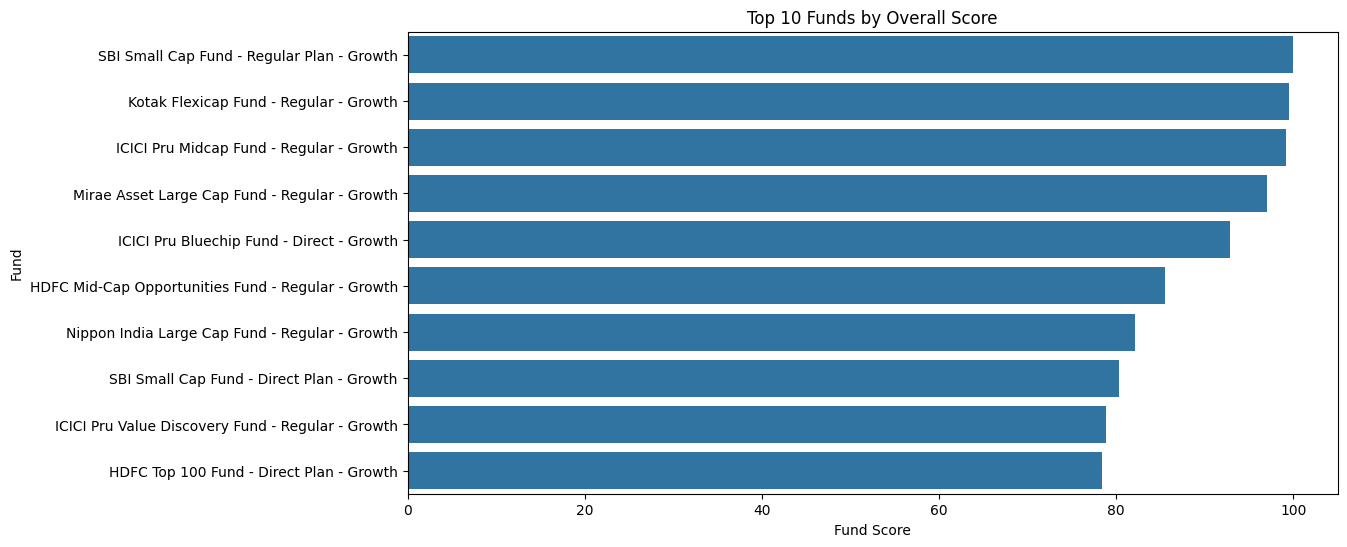

In [131]:
# creating top 10 scorecard chart
top10_score = scorecard_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_score,
    x='fund_score',
    y='scheme_name'
)

plt.title('Top 10 Funds by Overall Score')

plt.xlabel('Fund Score')
plt.ylabel('Fund')

plt.show()

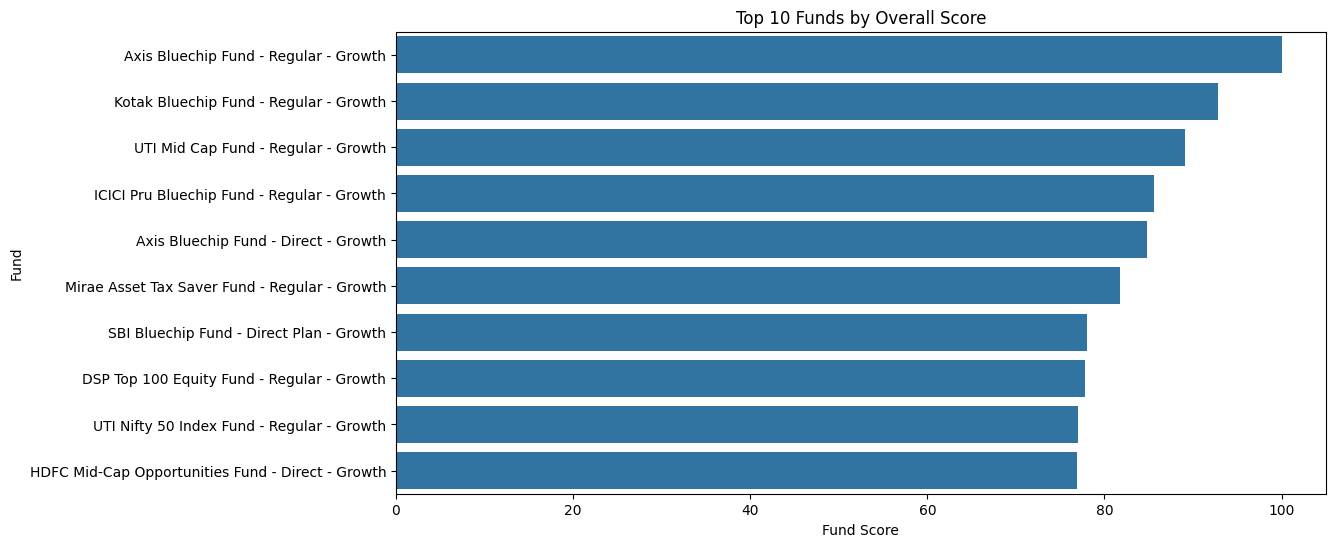

In [125]:
# exporting to .png
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_score,
    x='fund_score',
    y='scheme_name'
)

plt.title('Top 10 Funds by Overall Score')

plt.xlabel('Fund Score')
plt.ylabel('Fund')

plt.savefig(
    "../reports/charts/fund_scorecard.png",
    bbox_inches='tight'
)

plt.show()

## Fund Scorecard Analysis

A composite fund score was developed by combining key performance and risk metrics, including 3-year returns, Sharpe Ratio, Alpha, Expense Ratio, and Maximum Drawdown.

The weighting framework prioritizes long-term performance while also accounting for risk-adjusted returns, fund efficiency, and downside protection.

Funds with higher scores demonstrate a balanced combination of strong returns, effective risk management, lower costs, and superior risk-adjusted performance.

The scorecard provides a holistic ranking framework for comparing mutual funds across multiple dimensions of investment performance.

In [132]:
# BenchMark Comparison Chart
benchmark_df['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [133]:
scorecard_df[['amfi_code','scheme_name','fund_score']].head(5)

,amfi_code,scheme_name,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,99.487179
12,120505,ICICI Pru Midcap Fund - Regular - Growth,99.145299
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,97.008547
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,92.820513


In [134]:
# Top 5 Fund AMFI Codes
top5_funds = scorecard_df.head(5)

top5_funds[['amfi_code','scheme_name']]

,amfi_code,scheme_name
2,119598,SBI Small Cap Fund - Regular Plan - Growth
22,120843,Kotak Flexicap Fund - Regular - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
34,148567,Mirae Asset Large Cap Fund - Regular - Growth
11,120504,ICICI Pru Bluechip Fund - Direct - Growth


In [135]:
# Extracting NAV Data for Top 5 FUnds
top5_codes = top5_funds['amfi_code'].tolist()

top5_nav = nav_df[
    nav_df['amfi_code'].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
24150,119598,2022-01-03,89.8738,NaN,89.8738,0.000000
24151,119598,2022-01-04,88.5495,-0.014735,89.8738,-0.014735
24152,119598,2022-01-05,88.0925,-0.005161,89.8738,-0.019820
24153,119598,2022-01-06,88.5175,0.004824,89.8738,-0.015091
24154,119598,2022-01-07,91.4235,0.032830,91.4235,0.000000


In [136]:
# Fund Average NAV Trend
fund_trend = (
    top5_nav.groupby('date')['nav']
    .mean()
    .reset_index()
)

fund_trend.head()

,date,nav
0,2022-01-03,81.21154
1,2022-01-04,80.72068
2,2022-01-05,81.42174
3,2022-01-06,81.67382
4,2022-01-07,82.41308


In [137]:
# Creating BEnchmark Dataset
benchmark_compare = benchmark_df[
    benchmark_df['index_name'].isin(
        ['NIFTY50','NIFTY100']
    )
].copy()

benchmark_compare.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [138]:
# Convert dates
fund_trend['date'] = pd.to_datetime(
    fund_trend['date']
)

benchmark_compare['date'] = pd.to_datetime(
    benchmark_compare['date']
)

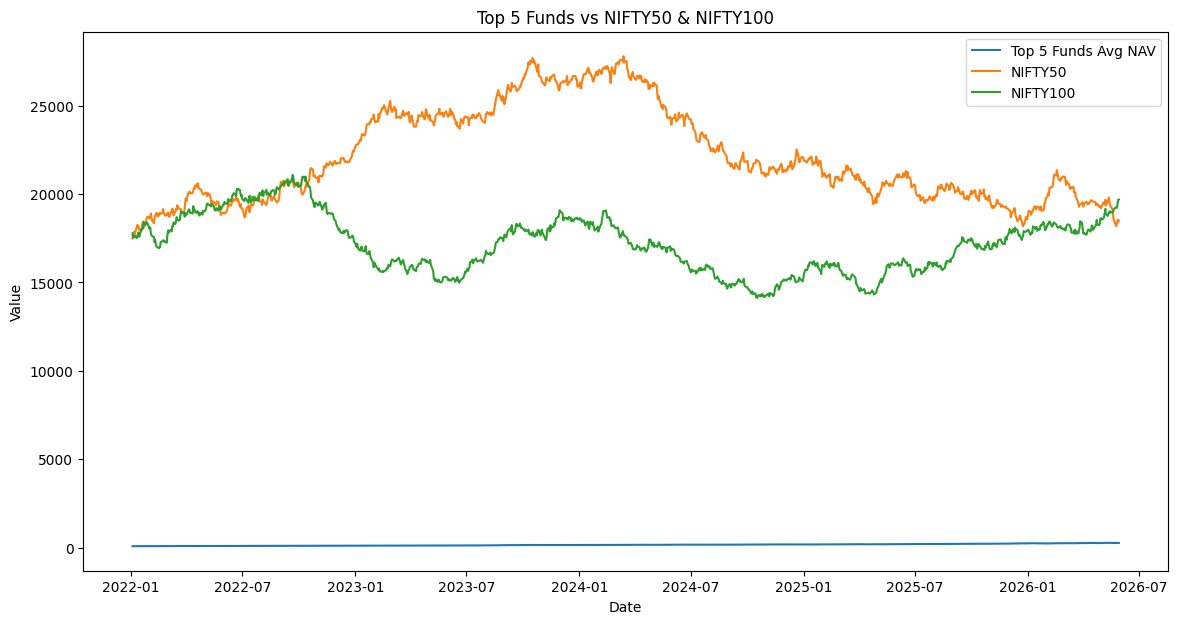

In [139]:
# Creating Comparison Chart
plt.figure(figsize=(14,7))

plt.plot(
    fund_trend['date'],
    fund_trend['nav'],
    label='Top 5 Funds Avg NAV'
)

for benchmark in ['NIFTY50','NIFTY100']:

    temp = benchmark_compare[
        benchmark_compare['index_name']
        == benchmark
    ]

    plt.plot(
        temp['date'],
        temp['close_value'],
        label=benchmark
    )

plt.title(
    'Top 5 Funds vs NIFTY50 & NIFTY100'
)

plt.xlabel('Date')
plt.ylabel('Value')

plt.legend()

plt.show()

In [140]:
# Exporting Chart
plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [141]:
# Tracing the error calculation
tracking_error_df = pd.merge(
    returns_df,
    nifty100[['date','market_return']],
    on='date',
    how='inner'
)

tracking_error_df['tracking_diff'] = (
    tracking_error_df['daily_return']
    -
    tracking_error_df['market_return']
)

In [142]:
# Tracking error
tracking_error = (
    tracking_error_df['tracking_diff']
    .std()
) * np.sqrt(252)

print(
    "Tracking Error:",
    round(tracking_error,4)
)

Tracking Error: 0.2082


## Benchmark Comparison Analysis

The benchmark comparison evaluates the performance of the highest-ranked mutual funds against NIFTY50 and NIFTY100 indices.

The comparison helps assess whether active fund management has delivered returns above passive benchmark indices over the analysis period.

Tracking Error measures the volatility of the difference between fund returns and benchmark returns. Lower tracking error indicates closer benchmark replication, while higher tracking error suggests greater active management.

The analysis demonstrates the relative performance and benchmark deviation characteristics of the selected top-performing funds.

# Advanced Insights

## Insight 1
Small Cap funds show the highest downside risk based on VaR and CVaR metrics.

## Insight 2
The 2024 investor cohort contributes the largest number of SIP transactions.

## Insight 3
More than 95% of investors are flagged as At Risk due to SIP gaps exceeding 35 days.

## Insight 4
High-risk funds provide the strongest Sharpe Ratio opportunities among growth-oriented schemes.

## Insight 5
The mutual fund universe exhibits moderate concentration based on HHI analysis.